In [1]:
from typing import Any

import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import zipfile
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from pathlib import Path

In [2]:
extract_dir = Path("./data")
if not extract_dir.exists():
  extract_dir.mkdir(parents=True, exist_ok=True)

In [3]:
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
with zipfile.ZipFile("./data/shape.zip", "r") as zip_ref:
  zip_ref.extractall(extract_dir)

In [5]:
shape_root = extract_dir / "shape"
train_dir = shape_root / "train"
test_dir = shape_root / "test"


print(train_dir)
print(test_dir)

data\shape\train
data\shape\test


# ImageFolder
하위 폴더 이름을 클래스 이름으로 사용하며, 알파벳 순서대로 클래스 번호를 지정함

In [6]:
raw_train = datasets.ImageFolder(train_dir)
raw_test = datasets.ImageFolder(test_dir)

In [7]:
print(raw_train[0])
print(raw_train[212])

(<PIL.Image.Image image mode=RGB size=28x28 at 0x2316E21FCB0>, 0)
(<PIL.Image.Image image mode=RGB size=28x28 at 0x2316E21FCB0>, 2)


In [8]:
print(raw_train.classes)
print(raw_train.class_to_idx)

['cir', 'tri', 'x']
{'cir': 0, 'tri': 1, 'x': 2}


# 전처리와 데이터 증강
이미지 크기를 resizing하기
> 모든 이미지를 1 x 28 x 28 로 변경하기 (그림판으로 그린거라 사진은 흑백이여도 
실제로는 3/4채널임)

> 또한 검정색이 0이기 때문에 검정색이 많은게 학습이 잘 될 수 있음.

> 픽셀 값을 텐서로 바꾼 뒤, 숫자의 범위를 스케일링 해주기 (정규화)

> 일반화 성능을 높이기 위해 학습 데이에만 회전/이동/크기 등을 변화시켜주기

In [9]:
train_transform = transforms.Compose([
    transforms.Resize((28, 28)), # 크기를 28 x 28 로 바꿔주기
    # 엄밀히 말하면 흑백과 다름. 흑백은 [0, 1] 와 같이 이진화 되어있는 상태임
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomInvert(p=1.0), # 모든 픽셀을 반전시켜주기. p는 probability
    transforms.RandomAffine(degrees=12, translate=(0.08, 0.08), scale=(0.90, 1.10)),
    # Tensor형으로 바꿔주기도 하지만 바뀌면서 스케일도 바꿔줌 (0 ~ 1)
    transforms.ToTensor(),
    # 중앙값을 0, 범위를 `-1 ~ 1`로 조정
    transforms.Normalize(mean=(0.5,), std=(0.5))
])

In [10]:
eval_transform = transforms.Compose([
  transforms.Resize((28, 28)),
  transforms.Grayscale(num_output_channels=1),
  transforms.RandomInvert(p=1.0),
  transforms.ToTensor(),
  transforms.Normalize(mean=(0.5,), std=(0.5))
])

# **4. 학습/검증/테스트 데이터 분리**
- 학습 데이터: 가중치를 실제로 업데이트
- 검증 데이터: 학습 중 모델 선택과 과적합 확인에 사용

In [11]:
base_dataset = datasets.ImageFolder(train_dir)
class_names = base_dataset.classes
num_classes = len(class_names)
num_classes

3

In [12]:
class_names

['cir', 'tri', 'x']

In [22]:
# 학습용 데이터
train_indices = []
# 검증용 데이터 (indices = 지수)
val_indices = []

# 난수 생성 객체
rng = np.random.default_rng(SEED)

for class_idx in range(num_classes):
    indices = np.where(np.array(base_dataset.targets) == class_idx)[0]
    rng.shuffle(indices)
    split = int(len(indices) * 0.8)
    train_indices.extend(indices[:split].tolist())
    val_indices.extend(indices[split:].tolist())

train_full = datasets.ImageFolder(train_dir, transform=train_transform)
val_full = datasets.ImageFolder(train_dir, transform=eval_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

# 기존 데이터셋에서 원하는 데이터만 선택하여 새로운 데이터셋을 생성
train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(val_full, val_indices)

print("학습:", len(train_dataset))
print("검증:", len(val_dataset))
print("테스트:", len(test_dataset))

학습: 192
검증: 48
테스트: 60


In [16]:
np.where(np.array(base_dataset.targets) == 0)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
        68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79]),)

In [25]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# **5. 이미지와 텐서 모양 확인**

- CNN 입력 텐서: [배치, 채널, 높이, 너비]
- 현재 데이터의 배치 shape: [32, 1, 28, 28]

In [26]:
images, labels = next(iter(train_loader))

print("images:", type(images), images.shape)
print("labels:", type(labels), labels.shape)

images: <class 'torch.Tensor'> torch.Size([32, 1, 28, 28])
labels: <class 'torch.Tensor'> torch.Size([32])


In [27]:
def denormalize(image):
    return image * 0.5 + 0.5

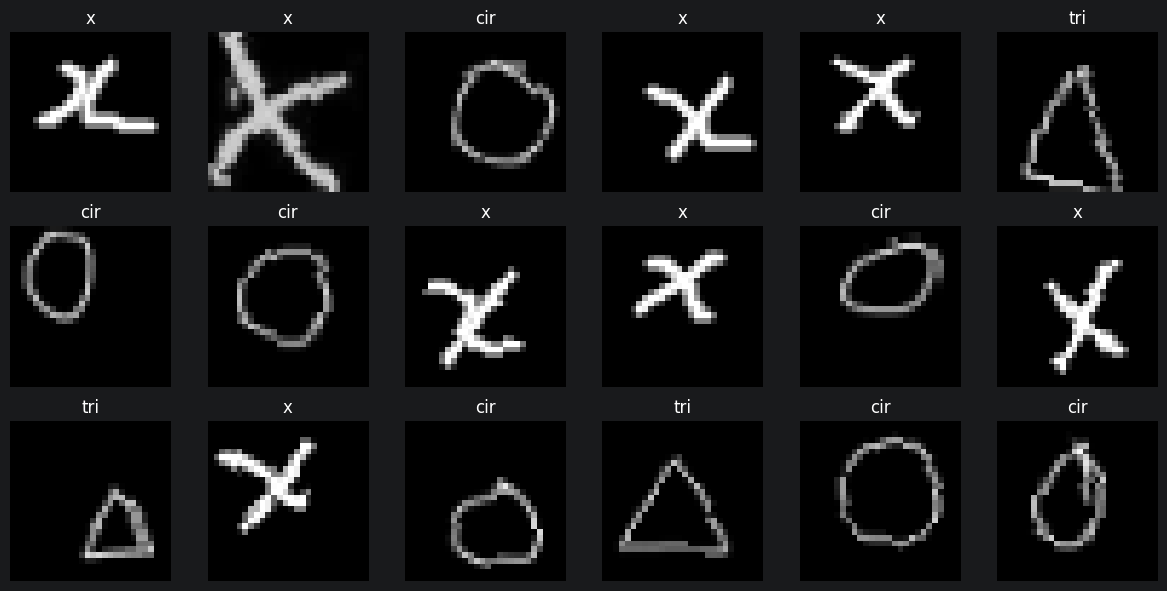

In [28]:
fig, axes = plt.subplots(3, 6, figsize=(12, 6))
for ax, image, label in zip(axes.flat, images[:18], labels[:18]):
    ax.imshow(denormalize(image).squeeze(0), cmap='gray', vmin=0, vmax=1)
    ax.set_title(class_names[label.item()])
    ax.axis('off')
plt.tight_layout()
plt.show()

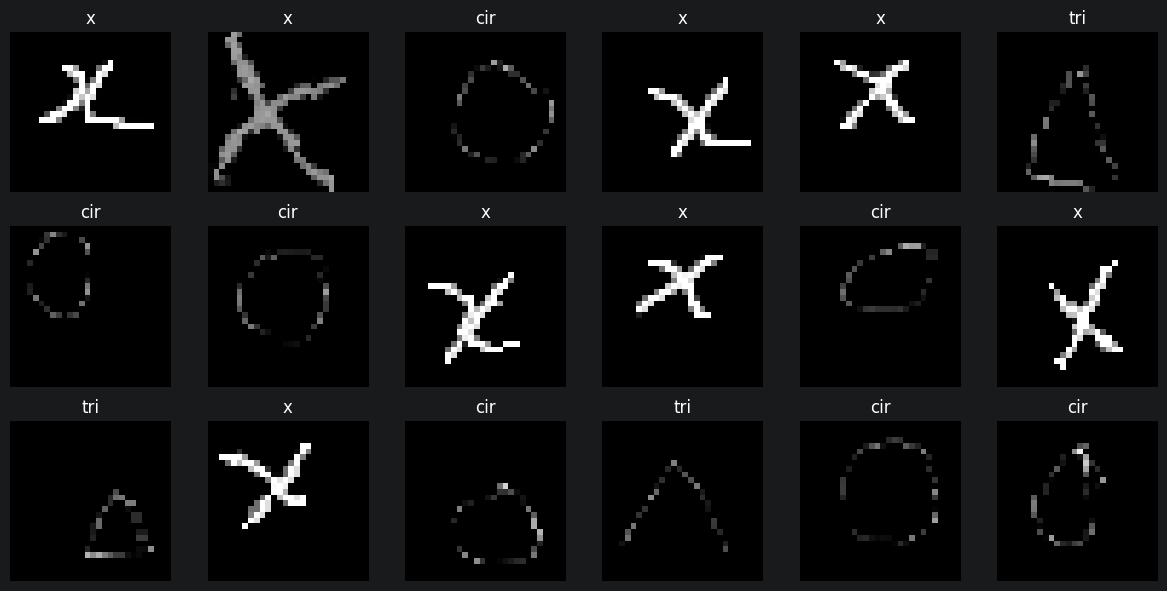

In [29]:
fig, axes = plt.subplots(3, 6, figsize=(12, 6))
for ax, image, label in zip(axes.flat, images[:18], labels[:18]):
    ax.imshow(image.squeeze(0), cmap='gray', vmin=0, vmax=1)
    ax.set_title(class_names[label.item()])
    ax.axis('off')
plt.tight_layout()
plt.show()

# CNN 모델

### BatchNorm2d
CNN이 학습하면서 만들어낸 각 채널(feature map)의 값들을 적절한 범위로 정규화해서 학습을 더 안정적으로 만들어주는 층

```
입력 이미지 > Conv2d > 32개의 Feature Map 생성 > batchNorm2d > 각 Fetature Map의 값들을 정규화 > ReLU
nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
nn.BatchNorm2d(32),
nn.ReLU()
```

> CNN의 Conv2d를 통과하면 값들이 여러가지로 변함. 처음 입력 이미지가 어느정도 정규화되어있어도 Conv2d를 통과하고 나면 가중치와 계산되면서 채널마다 값의 분포가 달라질 수 있음. BatchNorm은 값을 어느정도 정돈해서 다음 층으로 보내주는 역할을 함

## AdaptiveAvgPool2d
- 입력 이미지의 크기가 얼마이든 상관 없이 최종 출력 크기를 항상 특정 크기로 만들어주는 평균 풀링 레이어
- FC 완전연결계층 = 모든 노드가 연결되어있는 FC 레이어 (CNN 분류모델의 마지막 부분에서 자주 사용)

``````
# nn.AvgPool2d(kernel_size=2)

    1 3 2 4
    5 7 6 8
    2 4 1 3
    6 8 5 7

->

    4 5
    5 4

# nn.AdaptiveAvgPool2d((1, 1))
입력 크기가 어떻게 생겻든 최종적으로 1*1로 만들어줘

    1 3 2 4
    5 7 6 8
    2 4 1 3
    6 8 5 7

->

    4.5
``````

# Dropout
- 신경망이 학습할 때 일부 뉴런을 일부러 랜덤하게 꺼버리는 기법
- 과적합을 줄이기 위해 사용
- 네트워크에서 뉴런을 영구적으로 삭제하는 것이 아니며, 학습 순간에만 뉴런의 출력을 0으로 함
- model.train() Dropout 작동, model.eval() Dropout 꺼짐

> 일부 뉴런들의 집합끼리만

In [31]:
class ShapeCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            # 좋은 모델들은 어느정도 레이어를 n개로 나눠서 쓰기도 함(Conv 1 -> 64 보다는 1 -> 32, 32 -> 32 형태)
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            # inplace = 덮어쓰기 옵션 (기존 텐서값을 직접 변경하라는 뜻)
            # BatchNorm에서 넘어온 Tensor을 별도의 새로운 Tensor로 복사해서 처리하지 않고
            # Tensor의 메모리를 직접 수정하여 모리를 절약
            nn.ReLU(inplace=True),
            # 특징 추출하기
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            # 좋은 모델들은 어느정도 레이어를 n개로 나눠서 쓰기도 함(Conv 1 -> 64 보다는 1 -> 32, 32 -> 32 형태)
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            # inplace = 덮어쓰기 옵션 (기존 텐서값을 직접 변경하라는 뜻)
            # BatchNorm에서 넘어온 Tensor을 별도의 새로운 Tensor로 복사해서 처리하지 않고
            # Tensor의 메모리를 직접 수정하여 모리를 절약
            nn.ReLU(inplace=True),
            # 특징 추출하기
            nn.MaxPool2d(kernel_size=2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(p=0.25),
            nn.Linear(64*1*1, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [34]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(DEVICE)

cuda


In [35]:
model = ShapeCNN(num_classes=num_classes)
model

ShapeCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2

In [40]:
criterion = nn.CrossEntropyLoss()

# AdamW
- Adam에 가중치 감쇠(weight Decay)를 적용한 방식
- 딥러닝 모델의 가중치가 지나치게 커지면 학습 데이터가 너무 맞춰지는 과적합이 발생할 수 있음
- Weight Decay로 학습 중에 가중치를 조금씩 줄여서 너무 커지지 않도록 하는 방법을 사용

> 이전 학습률을 일정 비율만큼 가져와서 성능을 높이도록 만듦

```
Gradient > Adam의 적응적 계산 > 가중치 업데이트 > wegiht Decay를 적용
```

# 옵티마이저
> 학습하는 과정에서 Loss를 구한 다음에 손실을 통해 기울기를 재계산 -> 가중치 수정 ->

SGD -> 기본적인 옵티마이저 -> **원칙적으로는 데이터를 하나씩 넣어서 랜덤하게 데이터를 넣어서 기울기를 반영하는 알고리즘**, 배치로 잘라도 되고, 전체를 넣어도 등등 모두 정상 작동한다

In [37]:
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

### Scheduler
- 검증 성능이 더이상 좋아지지 않을 때 자동으로 학습률을 낮춰주는 기능
- 가중치 = 가중치 - 학습률 * 기울기
- 예) lr=0.1 -> lr=0.01


```
Epoch
> 전체 데이터를 한번 돌면서 학습에 쓴 것을 말

에포크 한번당 Loss값을 계산하게 됨.
Epoch_1 Loss = 0.8
Epoch_2 Loss = 0.6
Epoch_3 Loss = 0.5
Epoch_4 Loss = 0.43
Epoch_5 Loss = 0.40
Epoch_6 Loss = 0.42
Epoch_7 Loss = 0.41
Epoch_8 Loss = 0.42

>>> 자동으로 학습률을 낮추면서 더 좋아질 수 있는지를 확인
```

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

- mode: `min` - Loss가 최저값일 때 좋아졌다고 판단. 다른 것으로는 `max`가 존재함
- factor: 학습률을 반영하는 값
- patience: 몇 번까지 기다릴 것인지 (계속 Loss가 줄지 않으면? 아니면 최저값 이하로 내려가지 못하면?)


In [ ]:
# 스케줄러 만들기
# 변화가 없을 떄 lr을 줄이는 함수
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

# 학습과 평가 함수

In [42]:
def run_epoch(model, loader, criterion, device, optimizer=None):
    # 옵티마이저가 있어야 학습률을 적용하기 위해 현재 모델 학습 상태인지 저장하기
    is_training = optimizer is not None

    # 메모리에 옵티마이저를 올리고, 학습할 수 있는 여러 기능들을 올려주게 됨
    # train이면 옵티마이저를 메모리에서 꺼주고 (검증모드) + Dropout 꺼주기
    model.train() if is_training else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    # enable_grad: 기울기 계산을 활성화
    # inference_mode: 불필요한 기울기 계산 방지
    context = torch.enable_grad() if is_training else torch.inference_mode()

    with context:
        for images, labels in loader:
            # cpu메모리에서 gpu메모리로 이동시키는데 시간이 걸림
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if is_training:
                # set_to_none: 기울기 값을 0으로 채우는 대신에 None으로 설정
                # python GC의 정리 대상으로 만들어줌.
                # 불필요한 0 Tensor 생성을 줄일 수 있음
                optimizer.zero_grad(set_to_none=True)

            model = model.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            if is_training:
                loss.backward()
                optimizer.step()
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum()
            total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples

### 모델 학습과 Early Stopping
- 모델을 학습시키는 과정에서 메모리에 저장해두면 학습했던 내용을 날려버리게 될 수 있음.
- 따라서 지금까지 학습되어있는 가중치를 사용하기 위해 학습이 돌면서 검증 손실이 가장 낮을 때마다 저장하게 만들기

> 검증 손실이 가장 낮을 때의 가중치를 저장

> 일정 횟수동안 검증 손실이 개선되지 않으면 학습을 조기에 종료하여 과적합과 불필요한 학습을 줄임

In [39]:
EPOCHS = 50
EARLY_STOPPING_PATIENCE = 8

best_val_loss = float('inf')

wait = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

# 파이토치에서 가중치를 저장하는 확장명
best_model_path = "best_shape_cnn.pth"

# best_shape_cnn.h5

In [45]:
for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = run_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        device=DEVICE,
        optimizer=optimizer
    )

    val_loss, val_acc = run_epoch(
        model=model,
        loader=test_loader,
        criterion=criterion,
        device=DEVICE
    )

    print(f"\n --- [epoch:{epoch}] --- \n")
    print(
        "train_loss:", round(train_loss, 4),
        "train_acc:", round(train_acc.item(), 4),
        "val_loss:", round(val_loss, 4),
        "val_acc:", round(val_acc.item(), 4)
    )


 --- [epoch:1] --- 

train_loss: 0.0216 train_acc: 0.9948 val_loss: 0.0272 val_acc: 1.0

 --- [epoch:2] --- 

train_loss: 0.0073 train_acc: 1.0 val_loss: 0.1224 val_acc: 0.95

 --- [epoch:3] --- 

train_loss: 0.0107 train_acc: 1.0 val_loss: 0.0351 val_acc: 0.9833

 --- [epoch:4] --- 

train_loss: 0.0082 train_acc: 1.0 val_loss: 0.0098 val_acc: 1.0

 --- [epoch:5] --- 

train_loss: 0.0089 train_acc: 1.0 val_loss: 0.0519 val_acc: 0.9833

 --- [epoch:6] --- 

train_loss: 0.0135 train_acc: 0.9948 val_loss: 0.0147 val_acc: 0.9833

 --- [epoch:7] --- 

train_loss: 0.0074 train_acc: 1.0 val_loss: 0.0124 val_acc: 1.0

 --- [epoch:8] --- 

train_loss: 0.0048 train_acc: 1.0 val_loss: 0.0111 val_acc: 1.0

 --- [epoch:9] --- 

train_loss: 0.0105 train_acc: 0.9948 val_loss: 0.0041 val_acc: 1.0

 --- [epoch:10] --- 

train_loss: 0.0108 train_acc: 1.0 val_loss: 0.0138 val_acc: 0.9833

 --- [epoch:11] --- 

train_loss: 0.0069 train_acc: 1.0 val_loss: 0.136 val_acc: 0.95

 --- [epoch:12] --- 

train_l